<a href="https://colab.research.google.com/github/Abhishek0077-cs/cancer-survival-prediction/blob/main/ML_Mdels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv('lung_cancer_dataset.csv')
df.shape

(1500, 41)

In [4]:
df.describe()


,Diagnosis_Year,Age,Cigarettes_Per_Day,Years_Smoking,BMI,Tumor_Size_cm,Survival_Months
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,2020.630000,60.658000,7.404667,8.214667,26.537267,4.593333,31.150667
std,3.097014,10.298272,11.804087,12.775761,3.977224,2.388304,23.273097
min,2015.000000,30.000000,0.000000,0.000000,16.000000,0.500000,1.000000
25%,2018.000000,53.000000,0.000000,0.000000,23.800000,2.600000,11.000000
50%,2021.000000,60.000000,0.000000,0.000000,26.450000,4.400000,26.000000
75%,2023.000000,68.000000,14.000000,17.000000,29.400000,6.200000,48.000000
max,2025.000000,89.000000,56.000000,59.000000,40.000000,12.900000,109.000000


In [5]:
df.isnull().count()

,0
Patient_ID,1500
Diagnosis_Year,1500
Diagnosis_Date,1500
WHO_Region,1500
Country,1500
Age,1500
Gender,1500
Smoking_Status,1500
Cigarettes_Per_Day,1500
Years_Smoking,1500


In [6]:
df.head()

,Patient_ID,Diagnosis_Year,Diagnosis_Date,WHO_Region,Country,Age,Gender,Smoking_Status,Cigarettes_Per_Day,Years_Smoking,...,Finger_Clubbing,Cancer_Type,NSCLC_Subtype,Cancer_Stage,Tumor_Size_cm,Metastasis,Diagnosis_Method,Treatment,Survival_Months,Survived
0,LC-0001,2020,2020-11-04,Western Pacific,China,46,Female,Current Smoker,28,28,...,No,NSCLC,Adenocarcinoma,Stage IV,6.4,Yes,MRI,Chemo + Radiation,4,No
1,LC-0002,2020,2020-12-09,Americas,Mexico,71,Male,Former Smoker,5,34,...,No,NSCLC,Adenocarcinoma,Stage I,2.6,No,Biopsy,Surgery + Chemotherapy,76,Yes
2,LC-0003,2016,2016-04-05,Western Pacific,Japan,53,Female,Never Smoked,0,0,...,No,NSCLC,Squamous Cell,Stage I,2.9,No,LDCT Screening,Surgery,69,No
3,LC-0004,2017,2017-11-24,Western Pacific,Singapore,55,Male,Current Smoker,21,34,...,No,NSCLC,Adenocarcinoma,Stage IV,7.0,Yes,CT Scan,Chemotherapy,9,No
4,LC-0005,2023,2023-02-19,Western Pacific,Malaysia,54,Male,Never Smoked,0,0,...,No,NSCLC,Adenocarcinoma,Stage III,5.8,No,Bronchoscopy,Immunotherapy,5,Yes


In [177]:
columns=['Gender', 'Smoking_Status', 'Chronic_Lung_Disease', 'Genetic_Mutation', 'Treatment']
df[columns].head()

,Gender,Smoking_Status,Chronic_Lung_Disease,Genetic_Mutation,Treatment
0,Female,Current Smoker,Yes,No Mutation,Chemo + Radiation
1,Male,Former Smoker,No,KRAS,Surgery + Chemotherapy
2,Female,Never Smoked,No,KRAS,Surgery
3,Male,Current Smoker,Yes,No Mutation,Chemotherapy
4,Male,Never Smoked,Yes,KRAS,Immunotherapy


In [178]:
df.columns

Index(['Patient_ID', 'Diagnosis_Year', 'Diagnosis_Date', 'WHO_Region',
       'Country', 'Age', 'Gender', 'Smoking_Status', 'Cigarettes_Per_Day',
       'Years_Smoking', 'Secondhand_Smoke', 'Family_History',
       'Occupational_Hazard', 'Air_Pollution_Exposure', 'Alcohol_Use', 'BMI',
       'Exercise_Frequency', 'Chronic_Lung_Disease', 'Asbestos_Exposure',
       'Radon_Exposure', 'Previous_Cancer_History', 'Genetic_Mutation',
       'Coughing', 'Shortness_of_Breath', 'Chest_Pain', 'Coughing_Blood',
       'Fatigue', 'Weight_Loss', 'Wheezing', 'Recurrent_Infections',
       'Swallowing_Difficulty', 'Finger_Clubbing', 'Cancer_Type',
       'NSCLC_Subtype', 'Cancer_Stage', 'Tumor_Size_cm', 'Metastasis',
       'Diagnosis_Method', 'Treatment', 'Survival_Months', 'Survived'],
      dtype='object')

In [179]:
df.drop('Patient_ID',axis=1)

,Diagnosis_Year,Diagnosis_Date,WHO_Region,Country,Age,Gender,Smoking_Status,Cigarettes_Per_Day,Years_Smoking,Secondhand_Smoke,...,Finger_Clubbing,Cancer_Type,NSCLC_Subtype,Cancer_Stage,Tumor_Size_cm,Metastasis,Diagnosis_Method,Treatment,Survival_Months,Survived
0,2020,2020-11-04,Western Pacific,China,46,Female,Current Smoker,28,28,Yes,...,No,NSCLC,Adenocarcinoma,Stage IV,6.4,Yes,MRI,Chemo + Radiation,4,No
1,2020,2020-12-09,Americas,Mexico,71,Male,Former Smoker,5,34,Yes,...,No,NSCLC,Adenocarcinoma,Stage I,2.6,No,Biopsy,Surgery + Chemotherapy,76,Yes
2,2016,2016-04-05,Western Pacific,Japan,53,Female,Never Smoked,0,0,Yes,...,No,NSCLC,Squamous Cell,Stage I,2.9,No,LDCT Screening,Surgery,69,No
3,2017,2017-11-24,Western Pacific,Singapore,55,Male,Current Smoker,21,34,No,...,No,NSCLC,Adenocarcinoma,Stage IV,7.0,Yes,CT Scan,Chemotherapy,9,No
4,2023,2023-02-19,Western Pacific,Malaysia,54,Male,Never Smoked,0,0,No,...,No,NSCLC,Adenocarcinoma,Stage III,5.8,No,Bronchoscopy,Immunotherapy,5,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,2018,2018-07-12,Western Pacific,South Korea,55,Male,Former Smoker,5,11,No,...,No,NSCLC,Large Cell,Stage IV,8.6,Yes,CT Scan,Immunotherapy,1,No
1496,2017,2017-08-02,Eastern Mediterranean,Iraq,56,Male,Current Smoker,20,29,Yes,...,No,NSCLC,Adenocarcinoma,Stage IV,8.1,Yes,Bronchoscopy,Immunotherapy,3,No
1497,2016,2016-08-15,Americas,Argentina,60,Male,Never Smoked,0,0,Yes,...,No,NSCLC,Adenocarcinoma,Stage III,5.5,No,Bronchoscopy,Chemotherapy,11,No
1498,2017,2017-04-27,Africa,Ethiopia,68,Male,Current Smoker,22,33,No,...,No,NSCLC,Squamous Cell,Stage III,5.7,No,Chest X-Ray,Chemo + Radiation,19,Yes


In [260]:
features =['Age','BMI','Gender','Smoking_Status','Years_Smoking','Chronic_Lung_Disease','Diagnosis_Method' ,
  'Cancer_Type','Cancer_Stage', 'Metastasis', 'Tumor_Size_cm','Survived','Finger_Clubbing','Secondhand_Smoke','Cigarettes_Per_Day']

df_feature= df[features]

dummy = ['Gender', 'Smoking_Status', 'Cancer_Type','Finger_Clubbing','Secondhand_Smoke','Diagnosis_Method',]
df_final = pd.get_dummies(df_feature, columns=dummy, drop_first=True, dtype=int)


df_final.columns

Index(['Age', 'BMI', 'Years_Smoking', 'Chronic_Lung_Disease', 'Cancer_Stage',
       'Metastasis', 'Tumor_Size_cm', 'Survived', 'Cigarettes_Per_Day',
       'Gender_Male', 'Smoking_Status_Former Smoker',
       'Smoking_Status_Never Smoked', 'Cancer_Type_SCLC',
       'Finger_Clubbing_Yes', 'Secondhand_Smoke_Yes',
       'Diagnosis_Method_Bronchoscopy', 'Diagnosis_Method_CT Scan',
       'Diagnosis_Method_Chest X-Ray', 'Diagnosis_Method_LDCT Screening',
       'Diagnosis_Method_MRI', 'Diagnosis_Method_PET Scan'],
      dtype='object')

In [261]:
stage_map = {'Stage IV':4, 'Stage I':1,'Stage III':3,'Stage II':2}
df_final['Cancer_Stage'] = df_final['Cancer_Stage'].replace(stage_map)
print(df_final['Cancer_Stage'].unique())

lung_map = {'Yes':1, 'No':0}
df_final['Chronic_Lung_Disease'] = df_final['Chronic_Lung_Disease'].replace(lung_map)
df_final['Metastasis']= df_final['Metastasis'].replace(lung_map)
df_final['Survived']= df_final['Survived'].replace(lung_map)
df_final.head()

[4 1 3 2]


/tmp/ipykernel_658/1626445088.py:2: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

/tmp/ipykernel_658/1626445088.py:6: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

/tmp/ipykernel_658/1626445088.py:7: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

/tmp/ipykernel_658/1626445088.py:8: FutureWarning:

Downca

,Age,BMI,Years_Smoking,Chronic_Lung_Disease,Cancer_Stage,Metastasis,Tumor_Size_cm,Survived,Cigarettes_Per_Day,Gender_Male,...,Smoking_Status_Never Smoked,Cancer_Type_SCLC,Finger_Clubbing_Yes,Secondhand_Smoke_Yes,Diagnosis_Method_Bronchoscopy,Diagnosis_Method_CT Scan,Diagnosis_Method_Chest X-Ray,Diagnosis_Method_LDCT Screening,Diagnosis_Method_MRI,Diagnosis_Method_PET Scan
0,46,29.6,28,1,4,1,6.4,0,28,0,...,0,0,0,1,0,0,0,0,1,0
1,71,31.3,34,0,1,0,2.6,1,5,1,...,0,0,0,1,0,0,0,0,0,0
2,53,25.8,0,0,1,0,2.9,0,0,0,...,1,0,0,1,0,0,0,1,0,0
3,55,25.3,34,1,4,1,7.0,0,21,1,...,0,0,0,0,0,1,0,0,0,0
4,54,32.0,0,1,3,0,5.8,1,0,1,...,1,0,0,0,1,0,0,0,0,0


In [262]:

x = df_final.drop('Survived', axis=1)
y = df_final['Survived']

In [263]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score , classification_report,confusion_matrix

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,random_state=42,stratify=y)

model_rf = RandomForestClassifier()
model_rf.fit(x_train, y_train)

RandomForestClassifier()

In [264]:
y_pred_rf = model_rf.predict(x_test)
accuracy_score(y_test, y_pred_rf)

0.7688888888888888

In [268]:
from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression()
model_lr.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



LogisticRegression()

In [269]:
y_pred_lr = model_lr.predict(x_test)
accuracy_score(y_test, y_pred_lr)

0.76

In [270]:
from sklearn.tree import DecisionTreeClassifier
model_dt = DecisionTreeClassifier()
model_dt.fit(x_train,y_train)

DecisionTreeClassifier()

In [271]:
y_pred_dt = model_dt.predict(x_test)
accuracy_score(y_test, y_pred_dt)

0.7

In [272]:
from sklearn.neighbors import KNeighborsClassifier
model_knn = KNeighborsClassifier()
model_knn.fit(x_train,y_train)


KNeighborsClassifier()

In [273]:
y_pred_knn = model_knn.predict(x_test)
accuracy_score(y_test, y_pred_knn)


0.7133333333333334

In [274]:
from sklearn.model_selection import GridSearchCV
model_gs = GridSearchCV(estimator=RandomForestClassifier(),param_grid={'max_depth':[4,5,6,7,8],'criterion':['entropy','gini']})
model_gs.fit(x_train,y_train)

GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'criterion': ['entropy', 'gini'],
                         'max_depth': [4, 5, 6, 7, 8]})

In [275]:
y_pred_gs = model_gs.predict(x_test)
accuracy_score(y_test, y_pred_gs)

0.7533333333333333

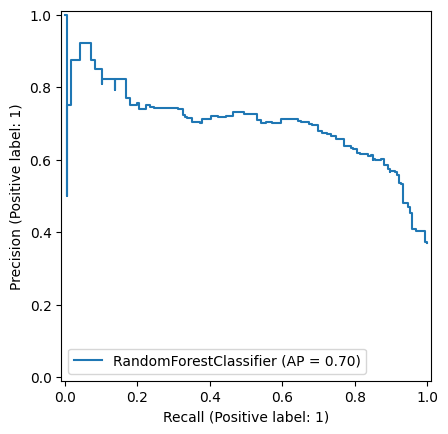

In [276]:
from sklearn.metrics import PrecisionRecallDisplay
PrecisionRecallDisplay.from_estimator(model_rf, x_test, y_test)

In [277]:
confusion_matrix(y_test, y_pred_gs)

array([[228,  56],
       [ 55, 111]])

<Axes: >

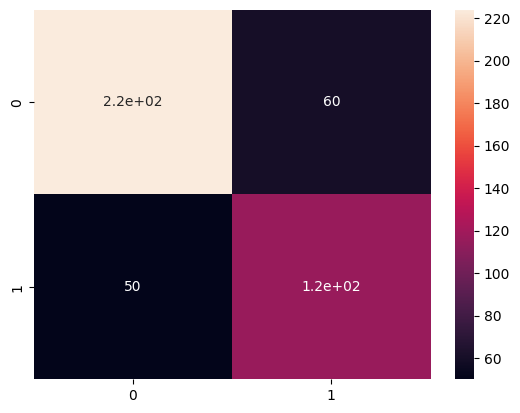

In [73]:
sns.heatmap(confusion_matrix(y_test, y_pred_gs), annot=True)

(array([-2.,  0.,  2.,  4.,  6.,  8., 10., 12., 14.]),
 [Text(-2.0, 0, '−2'),
  Text(0.0, 0, '0'),
  Text(2.0, 0, '2'),
  Text(4.0, 0, '4'),
  Text(6.0, 0, '6'),
  Text(8.0, 0, '8'),
  Text(10.0, 0, '10'),
  Text(12.0, 0, '12'),
  Text(14.0, 0, '14')])

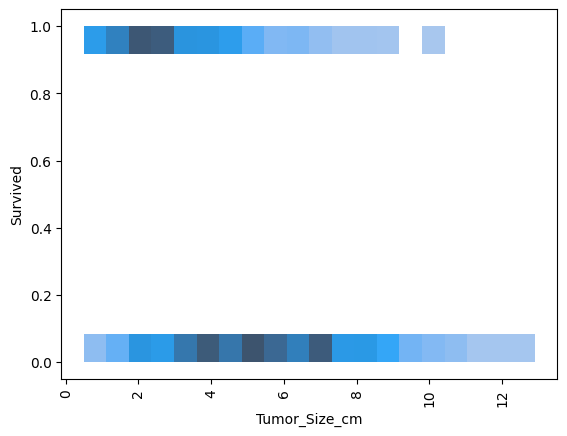

In [278]:
sns.histplot(data=df_final,x='Tumor_Size_cm',y='Survived',kde=True)
plt.xticks(rotation=90)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97,
  98,
  99,
  100,
  101,
  102,
  103,
  104,
  105,
  106,
  107,
  108,
  109,
  110,
  111,
  112,
  113,
  114,
  115,
  116,
  117,
  118,
  119,
  120,
  121,
  122,
  123,
  124,
  125,
  126,
  127,
  128,
  129,
  130,
  131,
  132,
  133,
  134,
  135,
  136,
  137,
  138,
  139,
  140,
  141,
  142,
  143,
  144,
  145,
  146,
  147,
  148,
  149,
  150,
  151,
  152,
  153,
  154,
  155,
  156,
  157,
  15

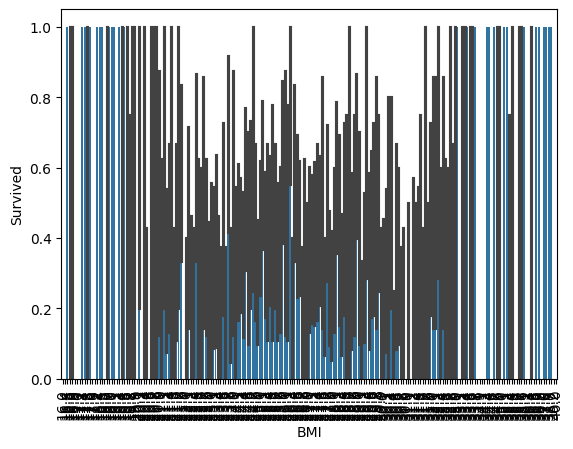

In [279]:
sns.barplot(data=df_final,x='BMI',y='Survived')
plt.xticks(rotation=90)

In [281]:
import plotly.graph_objects as go
features_3d = ['Age', 'Cancer_Stage', 'Tumor_Size_cm']
X_3d = df_final[features_3d]
y_3d = df_final['Survived']

model_3d = LogisticRegression().fit(X_3d, y_3d)
b = model_3d.intercept_[0]
w1, w2, w3 = model_3d.coef_[0]


x_range = np.linspace(X_3d['Age'].min(), X_3d['Age'].max(), 10)
y_range = np.linspace(X_3d['Cancer_Stage'].min(), X_3d['Cancer_Stage'].max(), 10)
xx, yy = np.meshgrid(x_range, y_range)

zz = -(w1 * xx + w2 * yy + b) / w3


fig = go.Figure()
fig.add_trace(go.Scatter3d(x=X_3d['Age'], y=X_3d['Cancer_Stage'], z=X_3d['Tumor_Size_cm'],
                           mode='markers', marker=dict(color=y_3d, colorscale='RdBu', opacity=0.6, size=5),
                           name='Patients'))


fig.add_trace(go.Surface(x=xx, y=yy, z=zz, opacity=0.5, showscale=False, name='Decision Boundary'))
fig.update_layout(scene=dict(xaxis_title='Age', yaxis_title='Stage', zaxis_title='Tumor Size'))
fig.show()




([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'No Mutation'),
  Text(1, 0, 'KRAS'),
  Text(2, 0, 'EGFR'),
  Text(3, 0, 'ROS1'),
  Text(4, 0, 'RET'),
  Text(5, 0, 'ALK'),
  Text(6, 0, 'HER2'),
  Text(7, 0, 'TP53'),
  Text(8, 0, 'BRAF'),
  Text(9, 0, 'MET')])

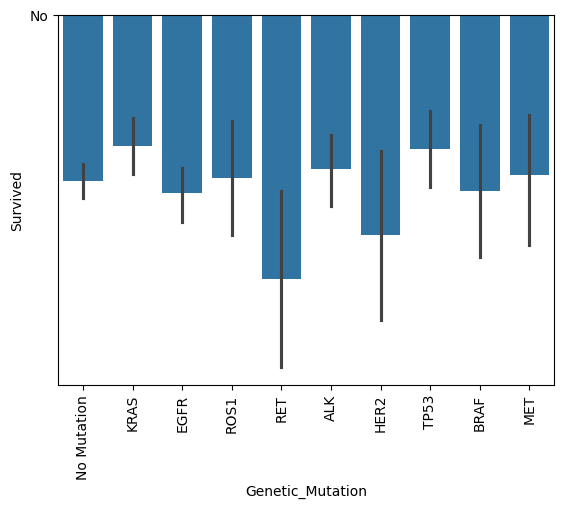

In [93]:
sns.barplot(data=df,x='Genetic_Mutation',y='Survived')
plt.xticks(rotation=90)

<Axes: xlabel='Family_History', ylabel='Survived'>

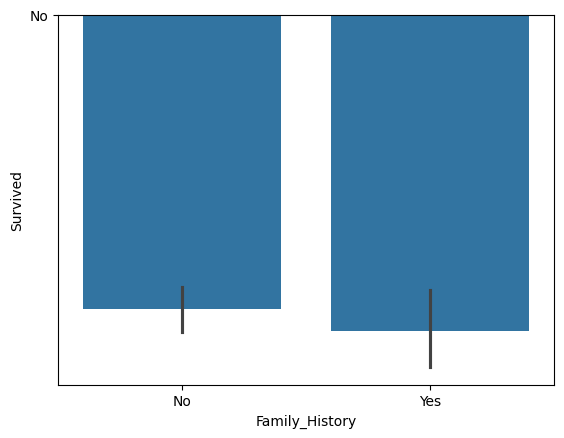

In [267]:
sns.barplot(data=df,x='Family_History',y='Survived')

<Axes: xlabel='Occupational_Hazard', ylabel='Survived'>

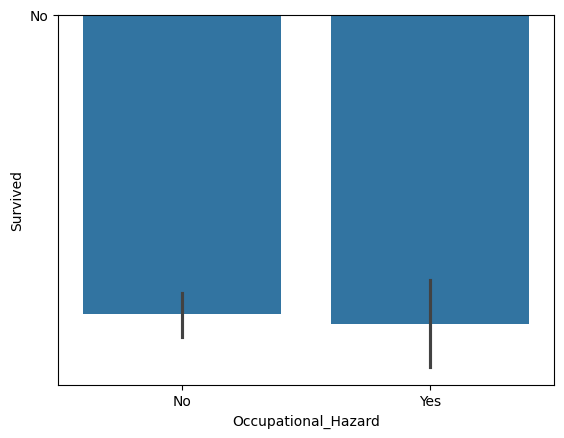

In [100]:
sns.barplot(data=df,x='Occupational_Hazard',y='Survived')

**Summary of this notebook**

**🩺 Cancer Survival Prediction**: A Machine Learning Approach
Developer: Abhishek Singh (@Abhishek-singhtech)

Project Focus: Predictive Analytics | Medical Data Science | Model Optimization

**📌 Project Overview**
This project aims to predict patient survival outcomes based on a comprehensive set of medical, environmental, and demographic features. The goal was to build a robust classification pipeline that balances raw accuracy with medical sensitivity (Recall).

**🛠️ Tech Stack & Workflow**
Data Processing: Pandas, NumPy

Visualization: Matplotlib, Seaborn, Plotly (3D Hyperplanes)

Machine Learning: Scikit-Learn (Logistic Regression, Decision Trees, Random Forest)

Optimization: GridSearchCV for hyperparameter tuning

**📊 Key Implementation Steps**
Feature Encoding: * Applied One-Hot Encoding for nominal data (Gender, Smoking Status).

Implemented Ordinal Mapping for Cancer Stages (I-IV) to preserve biological hierarchy.

Exploratory Data Analysis (EDA): Identified core correlations between Tumor Size, Age, and Metastasis as primary drivers of survival.

Model Benchmarking: Compared Linear (Logistic Regression) vs. Ensemble (Random Forest) models.

Hyperparameter Optimization: Utilized Grid Search to tune tree depth and estimators.

**📈 Results & Observations**
Model Accuracy: Stabilized at 77% across multiple algorithms.

The "Data Ceiling": Through rigorous tuning, it was observed that the model hit a performance plateau, likely due to inherent variance in the medical records or missing biological markers (e.g., genetic sequencing).

Decision Boundary: Visualized a 3D decision surface to analyze how the model separates survival classes in a multi-dimensional feature space.

**🚀 Future Improvements**
Implement SMOTE to handle class imbalance more aggressively.

Explore XGBoost for potential incremental accuracy gains.

Feature engineering of interaction terms (e.g., Age-Tumor interaction scores).